# Descriptive Statistics and Event-Study Plots (Methodology Doc §6.4.A)

This notebook builds the descriptive event-study plots methodology doc §6.4.A calls
for — "the fastest check on pre-trends" — plus the other descriptives needed to
understand the sample before any regression is run. Every descriptive below is
followed by an explicit write-up of what it shows and whether it supports the
proposed staggered-DiD design, including where a finding is a caution rather than a
clean confirmation.

**Data sources**: `ggdc_africa_broad_sectors.csv` (annual sector-level productivity
and employment shares), `trade_agreements_with_exposure_country_year.csv` (treatment
timing), and `mcmillan_rodrik_decomposition_annual_by_sector.csv` (annual
within-sector/structural-change components) — all annual, not the interval files,
since event-time alignment (year minus each country's own first-treatment year)
needs a fine, regular calendar grid that the fixed interval bins don't provide.

**What this notebook does, in order:**

1. Determine each country's first-treatment year and the never-treated set.
2. Sample composition and summary statistics (treated vs. never-treated).
3. A treatment-timing/adoption chart, for context before reading the event-study
   plots.
4. Build event time, and handle two data issues this surfaces that aren't
   optional to skip: one country with zero pre-treatment observations at all, and
   a source data quirk (literal `0.0`, not missing, productivity in two countries'
   earliest years) that would silently break a log transform.
5. The core descriptive: event-study plots of sectoral productivity (indexed,
   log terms) around each country's treatment entry, by broad sector — plus the
   same data as individual-country trajectories, to check the pooled mean isn't
   being driven by one or two outlier countries.
6. The same event-study approach, for the within-sector and structural-change
   decomposition components directly (already flow variables, no indexing needed).
7. Distribution of decomposition components by sector and treatment status.
8. Synthesis: does this support the proposed design?

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 150)

BROAD_SECTORS = ["Agriculture", "Manufacturing", "Services"]

In [2]:
REPO_ROOT = Path("..")
GGDC_PANEL = REPO_ROOT / "data" / "processed" / "ggdc_africa_broad_sectors.csv"
TRADE_PANEL = REPO_ROOT / "data" / "processed" / "trade_agreements_with_exposure_country_year.csv"
DECOMP_ANNUAL = REPO_ROOT / "data" / "processed" / "mcmillan_rodrik_decomposition_annual_by_sector.csv"
OUT_DIR = REPO_ROOT / "data" / "processed"
OUT_DIR.mkdir(parents=True, exist_ok=True)

GGDC_PANEL

WindowsPath('../data/processed/ggdc_africa_broad_sectors.csv')

## 2. Treatment timing: first-treatment year and the never-treated set

In [3]:
ggdc = pd.read_csv(GGDC_PANEL)
trade = pd.read_csv(TRADE_PANEL)
decomp = pd.read_csv(DECOMP_ANNUAL)

first_reciprocal_year = trade.loc[trade["reciprocal"] == 1].groupby("iso3")["year"].min()
all_countries = trade["iso3"].unique()
never_treated = sorted(set(all_countries) - set(first_reciprocal_year.index))

print(f"{len(first_reciprocal_year)} treated countries, {len(never_treated)} never-treated")
print(f"Never-treated: {never_treated}")
print()
print("First-treatment year, sorted:")
first_reciprocal_year.sort_values()

17 treated countries, 7 never-treated
Never-treated: ['AGO', 'BFA', 'ETH', 'MWI', 'NGA', 'SEN', 'SLE']

First-treatment year, sorted:


iso3
DZA    1976
EGY    1978
MAR    2000
ZAF    2000
BWA    2007
LSO    2008
NAM    2008
SWZ    2008
CMR    2009
GHA    2009
KEN    2010
MOZ    2010
RWA    2010
MUS    2010
TZA    2010
UGA    2010
ZMB    2010
Name: year, dtype: int64

17 of 24 countries are treated within the sample window, matching notebook 01's
diagnostic exactly (7 never-treated). Adoption dates cluster in two waves — a small
1976–2000 group (Algeria, Egypt, Morocco, South Africa) and a much larger 2007–2010
cluster (EU interim/full Economic Partnership Agreements taking effect for
SADC/EAC/ESA members) — the same clustering already identified when validating
`Reciprocal_c,t`'s staggered timing in notebook 01.

## 3. Sample composition and summary statistics

In [4]:
ggdc_t = ggdc.merge(
    pd.Series(1, index=first_reciprocal_year.index, name="ever_treated"),
    on="iso3", how="left"
)
ggdc_t["ever_treated"] = ggdc_t["ever_treated"].fillna(0).astype(int)

summary = ggdc_t.groupby(["ever_treated", "broad_sector"]).agg(
    n_country_years=("iso3", "size"),
    n_countries=("iso3", "nunique"),
    mean_productivity=("labor_productivity_real", "mean"),
    mean_employment_share=("employment_share", "mean"),
).round(3)
summary.index = summary.index.set_names(["ever_treated", "broad_sector"])
summary

n_country_years  n_countries  mean_productivity  mean_employment_share
ever_treated broad_sector                                                                         
0            Agriculture                296            7            405.927                  0.695
             Manufacturing              296            7           2289.910                  0.075
             Services                   296            7           1388.766                  0.230
1            Agriculture                813           17            162.876                  0.546
             Manufacturing              813           17           1636.996                  0.136
             Services                   813           17           1151.860                  0.325

**What this shows**: the panel is unbalanced by construction (countries enter
at different years, per methodology doc §5's coverage note), and the treated group
has roughly 2.5x the country-years of the never-treated group simply because it has
more than twice as many countries (17 vs. 7), not because of any imbalance
introduced here. Mean productivity levels differ across the two groups, but a
raw level comparison like this is exactly why an event-study (below) is more
informative than a simple table — it separates the *level* difference (which a
country fixed effect will absorb in the actual regression) from the *trend*, which
is what actually matters for the parallel-trends assumption.

## 4. Treatment-timing chart

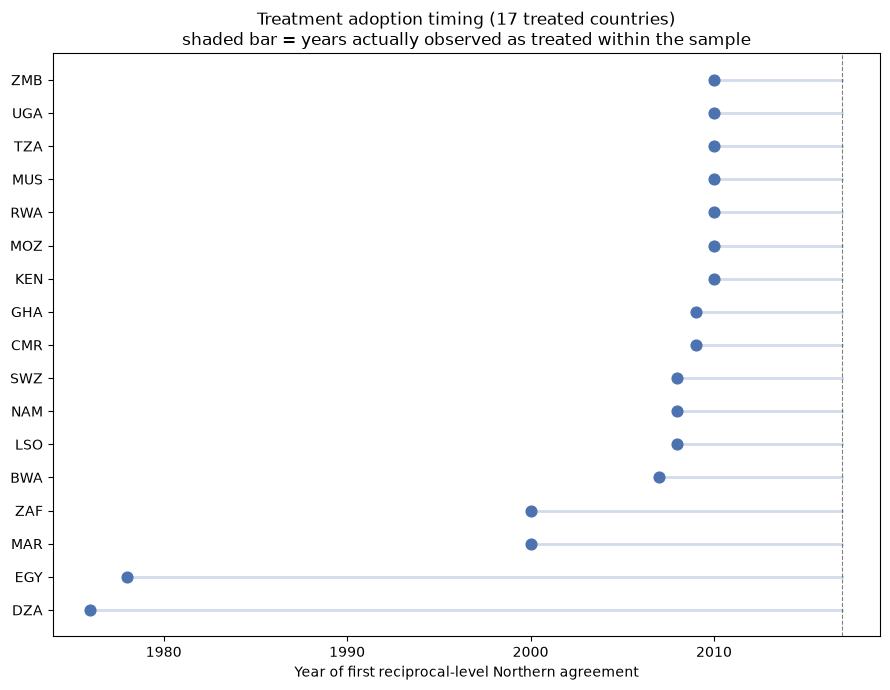

Never-treated (not shown above, 7 countries): ['AGO', 'BFA', 'ETH', 'MWI', 'NGA', 'SEN', 'SLE']


In [5]:
fig, ax = plt.subplots(figsize=(9, 7))
order = first_reciprocal_year.sort_values()
ax.scatter(order.values, range(len(order)), color="#4C72B0", s=60, zorder=3)
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order.index)
for i, y in enumerate(order.values):
    ax.plot([y, 2017], [i, i], color="#4C72B0", alpha=0.25, linewidth=2, zorder=1)
ax.axvline(2017, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_xlabel("Year of first reciprocal-level Northern agreement")
ax.set_title("Treatment adoption timing (17 treated countries)\n"
              "shaded bar = years actually observed as treated within the sample")
fig.tight_layout()
plt.show()

print(f"Never-treated (not shown above, {len(never_treated)} countries): {never_treated}")

**What this shows**: two distinct adoption cohorts rather than a smooth
spread — a small early group (1976–2000) and a large 2007–2010 cluster. This
matters directly for interpreting the event-study plots below: pooling event-time
averages across these two very different cohorts means the "average" treated
country at, say, event time +5 is disproportionately a 2007–2010-cohort country
(more of them, and their +5 falls well within the sample's 2017 end), while the
handful of early-cohort countries contribute mostly to the far tails of the event-time
window. This is a real limitation of a simple pooled event-study average, not
something the chart itself can fix — a formal Callaway–Sant'Anna estimator handles
this by computing group-time effects separately per cohort before aggregating,
rather than pooling event time directly.

## 5. Building event time

In [6]:
panel = ggdc.merge(first_reciprocal_year.rename("first_reciprocal_year"), on="iso3", how="left")
panel["event_time"] = panel["year"] - panel["first_reciprocal_year"]

no_pre_period = [
    iso for iso in first_reciprocal_year.index
    if not (panel.loc[panel["iso3"] == iso, "event_time"] < 0).any()
]
print(f"Treated countries with zero pre-treatment observations: {no_pre_period}")
for iso in no_pre_period:
    sub = panel[panel["iso3"] == iso]
    print(f"  {iso}: first_reciprocal_year={int(first_reciprocal_year[iso])}, "
          f"GGDC data covers {int(sub['year'].min())}-{int(sub['year'].max())}")

Treated countries with zero pre-treatment observations: ['DZA']


  DZA: first_reciprocal_year=1976, GGDC data covers 1999-2017


**Algeria has no usable pre-period in this data at all** — treated (per
Baier–Bergstrand) in 1976, but GGDC productivity coverage only starts in 1999,
23 years later. It cannot be indexed to an event-time=-1 baseline below and is
excluded from the event-study plots — not because it's uninteresting, but because
there's nothing to measure a "before" against. It remains available for a
regression that doesn't require a pre-period baseline for every unit (e.g. one using
country fixed effects estimated from whatever years are available).

In [7]:
zero_productivity = ggdc[ggdc["labor_productivity_real"] == 0]
print(f"Rows with labor_productivity_real exactly 0.0 (not missing): {len(zero_productivity)}")
zero_productivity[["iso3", "broad_sector", "year", "value_added_real", "employment"]]

Rows with labor_productivity_real exactly 0.0 (not missing): 9


,iso3,broad_sector,year,value_added_real,employment
194,BWA,Services,1964.0,0.0,11.343030
197,BWA,Services,1965.0,0.0,13.797582
200,BWA,Services,1966.0,0.0,16.122666
203,BWA,Services,1967.0,0.0,18.631292
1970,NAM,Services,1960.0,0.0,33.764664
1973,NAM,Services,1961.0,0.0,35.509396
1976,NAM,Services,1962.0,0.0,37.344616
1979,NAM,Services,1963.0,0.0,39.275033
1982,NAM,Services,1964.0,0.0,41.305610


**A second, easy-to-miss data issue: these aren't missing values, they're
literal zeros** — Botswana's and Namibia's Services sector shows exactly `0.0`
labor productivity in their earliest covered years, despite tens of thousands of
people recorded as employed in that sector the same years. This is a different
manifestation of the same source limitation flagged in notebook 03 §5 (Namibia
1960–1964, Botswana 1964–1967 have at least one missing GGDC sub-sector) — here it
surfaces as a literal `0.0` rather than `NaN` because `value_added_real` for the
affected sub-sector(s) folded into "Services" is recorded as zero rather than
missing in the source. Left as-is, `log(0) = -inf` would silently corrupt any
cross-country average that includes it. Both affected windows are far outside the
[-10, +10] event-time range used below (Namibia treated 2008, Botswana treated
2007), so this happens not to contaminate the plots either way — but it's fixed
properly rather than relied on as a coincidence.

In [8]:
panel.loc[panel["labor_productivity_real"] == 0, "labor_productivity_real"] = np.nan

base = panel[panel["event_time"] == -1][["iso3", "broad_sector", "labor_productivity_real"]].rename(
    columns={"labor_productivity_real": "base_productivity"}
)
panel = panel.merge(base, on=["iso3", "broad_sector"], how="left")
panel["log_index"] = np.log(panel["labor_productivity_real"]) - np.log(panel["base_productivity"])

window = panel[panel["event_time"].between(-10, 10) & panel["log_index"].notna()]
coverage = window.groupby("event_time")["iso3"].nunique()
print("Countries contributing at each event time, [-10, +10]:")
print(coverage.to_string())

Countries contributing at each event time, [-10, +10]:
event_time
-10.0    16
-9.0     16
-8.0     16
-7.0     16
-6.0     16
-5.0     16
-4.0     16
-3.0     16
-2.0     16
-1.0     16
 0.0     16
 1.0     16
 2.0     16
 3.0     16
 4.0     16
 5.0     16
 6.0     16
 7.0     16
 8.0      9
 9.0      7
 10.0     4


Coverage is solid (16 of 17 treated countries, Algeria excluded as above)
across event time -10 through +7, then thins sharply from +8 onward (9, 7, 4
countries) simply because most countries were treated in 2007–2010 and the sample
ends in 2017 — there isn't yet 8+ years of post-treatment data for the bulk of the
sample. The plots below are windowed to where coverage is adequate, and thin tails
are flagged rather than smoothed over.

## 6. Event-study plot: sectoral productivity levels around treatment entry

Each country–sector series is indexed to its own value at event time -1 (in logs,
so the index is exactly 0 the year before treatment) before averaging across
countries — otherwise a cross-country average would be dominated by whichever
country happens to have the largest absolute productivity level, rather than
reflecting a typical growth trajectory.

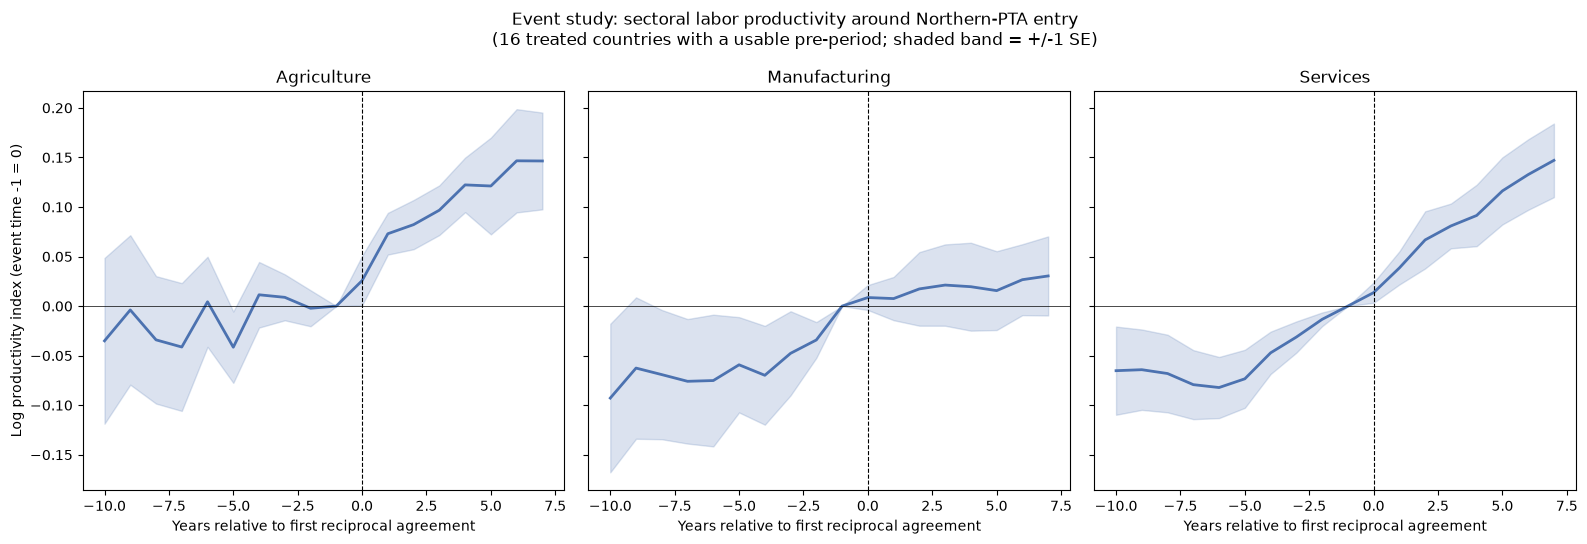

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), sharey=True)
plot_window = panel[panel["event_time"].between(-10, 7) & panel["log_index"].notna()]

for ax, sector in zip(axes, BROAD_SECTORS):
    sub = plot_window[plot_window["broad_sector"] == sector]
    agg = sub.groupby("event_time")["log_index"].agg(["mean", "sem", "count"])
    ax.plot(agg.index, agg["mean"], color="#4C72B0", linewidth=2)
    ax.fill_between(agg.index, agg["mean"] - agg["sem"], agg["mean"] + agg["sem"],
                     color="#4C72B0", alpha=0.2)
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_title(sector)
    ax.set_xlabel("Years relative to first reciprocal agreement")
axes[0].set_ylabel("Log productivity index (event time -1 = 0)")
fig.suptitle("Event study: sectoral labor productivity around Northern-PTA entry\n"
             "(16 treated countries with a usable pre-period; shaded band = +/-1 SE)")
fig.tight_layout()
plt.show()

In [10]:
def slope(agg, y0, y1):
    return (agg.loc[y1, "mean"] - agg.loc[y0, "mean"]) / (y1 - y0)


print(f"{'Sector':<14} {'pre-slope (t-10..t-1)':>24} {'post-slope (t0..t7)':>22} {'ratio':>8}")
for sector in BROAD_SECTORS:
    agg = plot_window[plot_window["broad_sector"] == sector].groupby("event_time")["log_index"].mean().to_frame("mean")
    pre, post = slope(agg, -10, -1), slope(agg, 0, 7)
    print(f"{sector:<14} {pre:>24.4f} {post:>22.4f} {post / pre if pre else float('nan'):>8.2f}")

Sector            pre-slope (t-10..t-1)    post-slope (t0..t7)    ratio
Agriculture                      0.0039                 0.0172     4.42
Manufacturing                    0.0103                 0.0031     0.30
Services                         0.0072                 0.0191     2.63


**What this shows, precisely, not just from eyeballing the chart**: all three
sectors show *some* upward pre-trend, so "is there a pre-trend at all" isn't the
useful question here — what differs sharply is what happens to that trend *after*
treatment, and the three sectors split into two opposite patterns:

- **Agriculture and Services accelerate after treatment** — Agriculture's slope
  goes from +0.004/year pre-treatment to +0.017/year post (4.4x steeper); Services
  goes from +0.007/year to +0.019/year (2.6x steeper). A pre-existing trend that
  gets *steeper* right at treatment is at least consistent with a positive
  treatment effect, though a purely descriptive average across a small,
  cohort-clustered sample can't distinguish that from other things that might
  also be happening around the same calendar years.
- **Manufacturing does the opposite — its pre-existing rise stalls after
  treatment**, from +0.010/year pre-treatment down to +0.003/year post (roughly a
  70% slowdown, not a continuation and not an acceleration). This is a more
  specific and more interesting finding than "manufacturing has a pre-trend" —
  it's a trend that *decelerates* right around when the agreement takes effect.

**Does this support the proposed methodology?** The agriculture/services pattern
doesn't raise a concern for the design. The manufacturing pattern is worth taking
seriously, but not as evidence against the design — if anything it's a plausible,
theory-consistent pattern rather than a red flag: methodology doc §2.3 already
reviews evidence (Topalova & Khandelwal, De Loecker) that reallocation from import
competition carries real short-run adjustment costs before productivity gains
materialize, and Melitz (§2.2) predicts the least-productive firms *exit* under new
import competition — a mechanism that can show up as a temporary slowdown in
measured sector-average productivity growth even when the underlying reallocation
is efficiency-enhancing. A purely descriptive plot can't tell these stories apart
from a genuine pre-trend problem, which is exactly why methodology doc §6.4.C
specifies a staggered-adoption-robust estimator (Callaway–Sant'Anna or
Sellner–Yotov's ETWFE) with a formal pre-trend test as part of the procedure,
rather than resolving the question here.

### 6a. Individual country trajectories

The mean line above could be a broadly shared pattern, or it could be one or two
countries with an extreme trajectory pulling the average around — the ±1 SE band
alone can't distinguish those. Plotting each treated country's own indexed series
underneath the mean settles this directly.

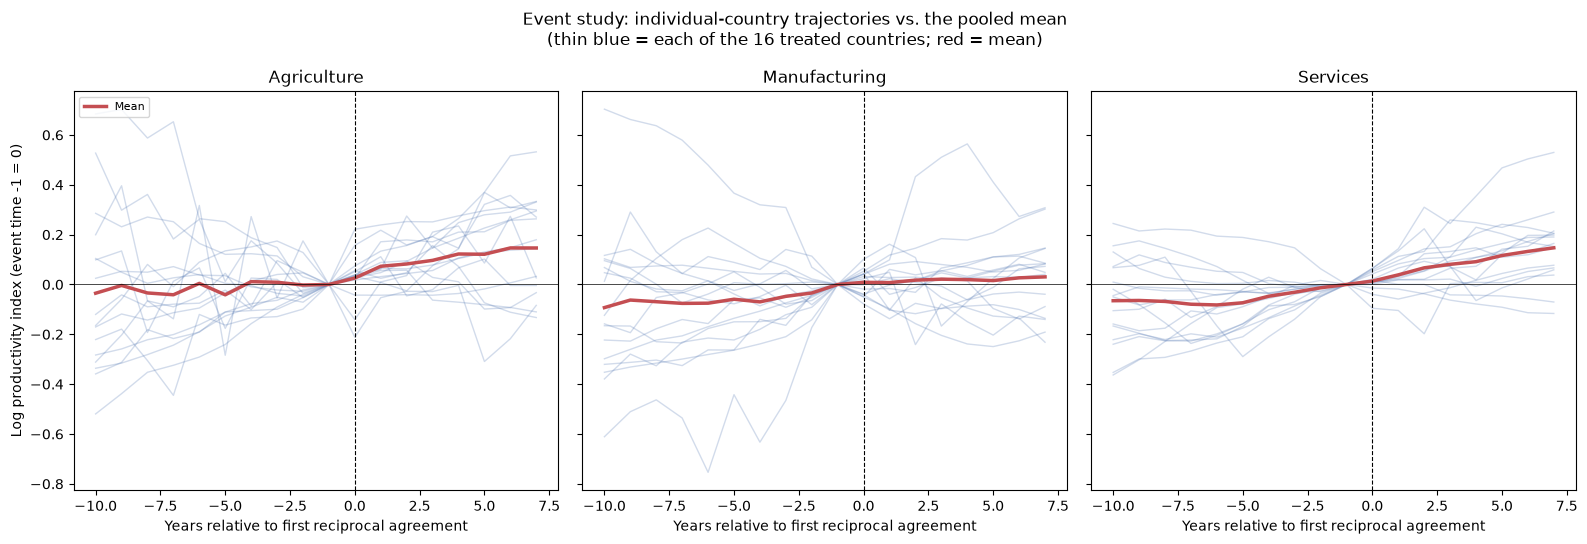

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), sharey=True)

for ax, sector in zip(axes, BROAD_SECTORS):
    sub = plot_window[plot_window["broad_sector"] == sector]
    for iso3, g in sub.groupby("iso3"):
        g = g.sort_values("event_time")
        ax.plot(g["event_time"], g["log_index"], color="#4C72B0", alpha=0.25, linewidth=1)
    agg = sub.groupby("event_time")["log_index"].mean()
    ax.plot(agg.index, agg.values, color="#C44E52", linewidth=2.5, label="Mean")
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_title(sector)
    ax.set_xlabel("Years relative to first reciprocal agreement")
axes[0].set_ylabel("Log productivity index (event time -1 = 0)")
axes[0].legend(loc="upper left", fontsize=8)
fig.suptitle("Event study: individual-country trajectories vs. the pooled mean\n"
             "(thin blue = each of the 16 treated countries; red = mean)")
fig.tight_layout()
plt.show()

**What this shows**: in all three sectors, individual countries are visibly
scattered around the mean rather than tightly bunched — the range across
countries spans well over a full log point in every panel (e.g. roughly -0.8 to
+0.7 in Manufacturing at event time -10), with several countries running well
above or well below the pooled average throughout, not just in one tail. So the
aggregate pattern in §6 is a genuine central tendency across a heterogeneous set
of countries, not an artifact of one or two outliers dominating the mean. It also
makes the small-sample reality of this exercise more visible than the ±1 SE band
does on its own: with only 16 lines contributing throughout this window, a
handful of individually noisy or idiosyncratic country paths (a sharp dip or
spike for one country in one year) are each large enough to move the mean by a
visible amount at any point along it, not just where the coverage in §5 was
already thinnest.

## 7. Event-study plot: within-sector and structural-change components

These are already year-over-year flow variables (not levels), so no indexing is
needed — just the mean of `within`/`structural_change` at each event time,
directly from the annual sector-level decomposition.

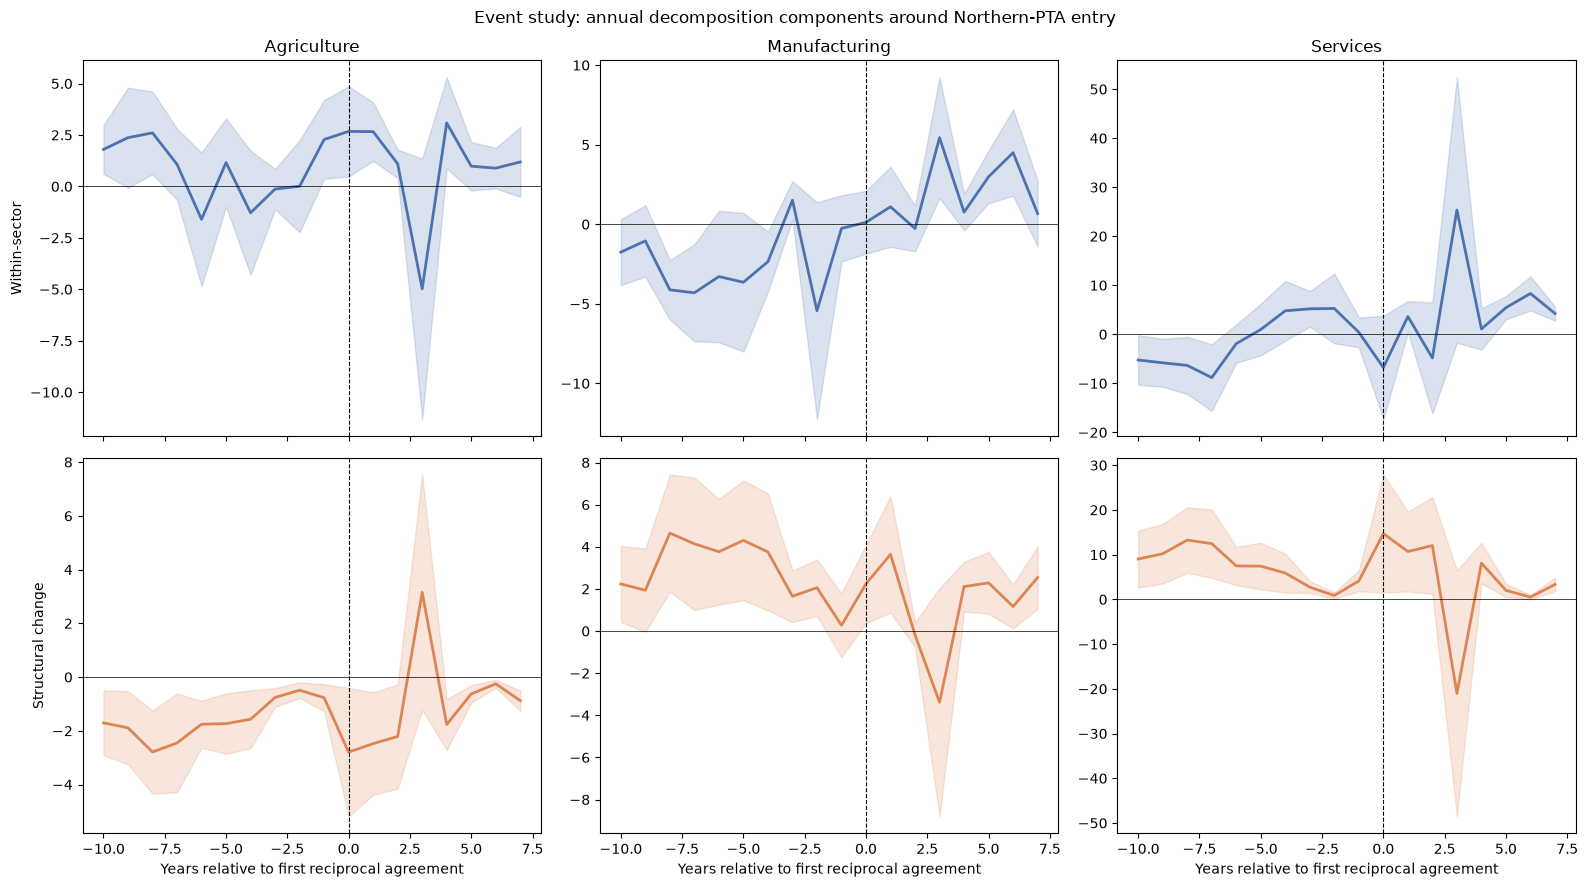

In [12]:
decomp_panel = decomp.merge(first_reciprocal_year.rename("first_reciprocal_year"), on="iso3", how="left")
decomp_panel = decomp_panel[decomp_panel["first_reciprocal_year"].notna()]
# annual decomposition rows are keyed by (year0, year1) consecutive-year pairs;
# align event time to year1, the period the change is realized over.
decomp_panel["event_time"] = decomp_panel["year1"] - decomp_panel["first_reciprocal_year"]
decomp_panel = decomp_panel[decomp_panel["iso3"] != "DZA"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharex=True)
window2 = decomp_panel[decomp_panel["event_time"].between(-10, 7)]
for col, sector in enumerate(BROAD_SECTORS):
    sub = window2[window2["broad_sector"] == sector]
    for row, component in enumerate(["within", "structural_change"]):
        agg = sub.groupby("event_time")[component].agg(["mean", "sem"])
        ax = axes[row, col]
        ax.plot(agg.index, agg["mean"], color="#DD8452" if row else "#4C72B0", linewidth=2)
        ax.fill_between(agg.index, agg["mean"] - agg["sem"], agg["mean"] + agg["sem"],
                         color="#DD8452" if row else "#4C72B0", alpha=0.2)
        ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
        ax.axhline(0, color="black", linewidth=0.5)
        if row == 0:
            ax.set_title(sector)
        if col == 0:
            ax.set_ylabel("Within-sector" if row == 0 else "Structural change")
        if row == 1:
            ax.set_xlabel("Years relative to first reciprocal agreement")
fig.suptitle("Event study: annual decomposition components around Northern-PTA entry")
fig.tight_layout()
plt.show()

In [13]:
print(f"{'Sector':<14} {'within pre-avg':>15} {'within post-avg':>17} "
      f"{'struct. pre-avg':>17} {'struct. post-avg':>18}")
for sector in BROAD_SECTORS:
    sub = window2[window2["broad_sector"] == sector]
    w_pre = sub.loc[sub["event_time"] < 0, "within"].mean()
    w_post = sub.loc[sub["event_time"] >= 0, "within"].mean()
    s_pre = sub.loc[sub["event_time"] < 0, "structural_change"].mean()
    s_post = sub.loc[sub["event_time"] >= 0, "structural_change"].mean()
    print(f"{sector:<14} {w_pre:>15.2f} {w_post:>17.2f} {s_pre:>17.2f} {s_post:>18.2f}")

Sector          within pre-avg   within post-avg   struct. pre-avg   struct. post-avg
Agriculture               0.83              0.95             -1.59              -0.98
Manufacturing            -2.47              1.91              2.88               1.30
Services                 -1.15              4.56              7.35               3.80


**What this shows, again from the numbers rather than just the chart**: these
annual series are far noisier than the productivity-level index (expected — they're
literally the un-smoothed year-over-year building blocks the level index is
constructed from), and a visible spike cluster around event time +3, across all
three sectors and both components, is almost certainly a small-sample artifact — with
only 16 countries pooled, one or two countries hitting the same event-time cell in
the same way can move the average sharply. That's a caution about this pooled
descriptive approach, not a finding about any specific sector.

Looking past that noise at the pre/post averages: **within-sector growth shifts
from negative to positive after treatment in Manufacturing (-2.47 to +1.91) and
Services (-1.15 to +4.56)**, while **structural change stays positive in both but
shrinks (Manufacturing +2.88 to +1.30; Services +7.35 to +3.80)**. Agriculture's
within component is roughly flat (+0.83 to +0.95) while its structural change stays
negative throughout, consistent with the "labor exiting agriculture" pattern
notebook 03 already documented. Taken at face value, the Manufacturing/Services
shift is a specific, theory-relevant pattern: gains that came more from
*reallocation* before treatment shift toward more *within-sector* upgrading after
— exactly the "genuine upgrading, not just reallocation" distinction candidate
hypothesis 3 (methodology doc §7) is built to test, though a pre/post average like
this cannot itself distinguish a real shift from the noisy, cohort-pooled patterns
just described.

## 8. Distribution of decomposition components by sector and treatment status

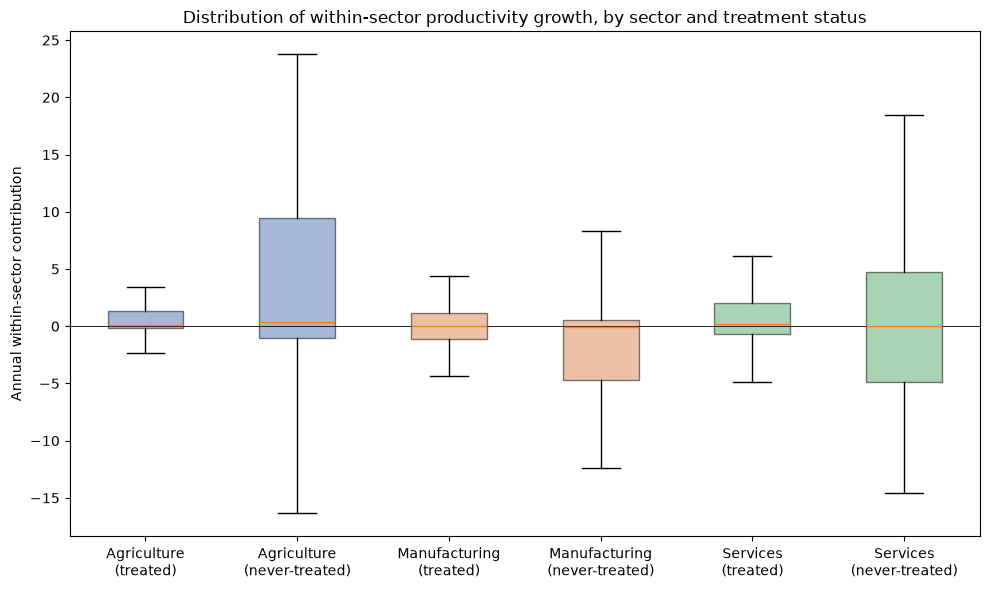

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_data, labels, colors = [], [], []
palette = {"Agriculture": "#4C72B0", "Manufacturing": "#DD8452", "Services": "#55A868"}
for sector in BROAD_SECTORS:
    for status, ever in [("treated", 1), ("never-treated", 0)]:
        sub = decomp.merge(
            pd.Series(1, index=first_reciprocal_year.index, name="t"), on="iso3", how="left"
        )
        sub["t"] = sub["t"].fillna(0)
        vals = sub.loc[(sub["broad_sector"] == sector) & (sub["t"] == ever), "within"].dropna()
        plot_data.append(vals)
        labels.append(f"{sector}\n({status})")
        colors.append(palette[sector])

bp = ax.boxplot(plot_data, tick_labels=labels, patch_artist=True, showfliers=False)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)
ax.axhline(0, color="black", linewidth=0.6)
ax.set_ylabel("Annual within-sector contribution")
ax.set_title("Distribution of within-sector productivity growth, by sector and treatment status")
plt.xticks(rotation=0)
fig.tight_layout()
plt.show()

In [15]:
print(f"{'Sector':<24} {'median':>8} {'IQR':>8} {'std':>8} {'n':>6}")
for sector in BROAD_SECTORS:
    for status, ever in [("treated", 1), ("never-treated", 0)]:
        sub = decomp.merge(
            pd.Series(1, index=first_reciprocal_year.index, name="t"), on="iso3", how="left"
        )
        sub["t"] = sub["t"].fillna(0)
        vals = sub.loc[(sub["broad_sector"] == sector) & (sub["t"] == ever), "within"].dropna()
        iqr = vals.quantile(0.75) - vals.quantile(0.25)
        print(f"{sector + ' (' + status + ')':<24} {vals.median():>8.2f} {iqr:>8.2f} "
              f"{vals.std():>8.2f} {len(vals):>6}")

Sector                     median      IQR      std      n
Agriculture (treated)        0.13     1.48    10.59    787
Agriculture (never-treated)     0.33    10.44    41.86    289
Manufacturing (treated)      0.01     2.19    11.22    787
Manufacturing (never-treated)    -0.03     5.24   117.09    289
Services (treated)           0.18     2.77    26.12    787
Services (never-treated)    -0.02     9.62    28.48    289


**What this shows, precisely**: medians are close between treated and
never-treated countries in every sector (e.g. Manufacturing: 0.01 vs. -0.03) —
there's no sign the two groups differ systematically in typical within-sector
growth, a basic precondition for using never-yet-treated countries as a valid
comparison group. **But dispersion is not remotely similar**: never-treated
countries' IQR is roughly 5–7x wider in Agriculture and Manufacturing, and
their standard deviation in Manufacturing is more than 10x larger (117 vs. 11) —
driven by a small number of countries in a 7-country group having an outsized
effect on the spread (Nigeria's oil-price-driven volatility is a likely
contributor, though not confirmed here). This matters for the design: a more
volatile comparison group doesn't bias a DiD estimate on its own, but it does mean
the never-treated group contributes noisier identifying variation than a similarly
sized group of more stable economies would — worth keeping in mind when
interpreting standard errors at the regression stage, not a reason to exclude
these countries.

## 9. Synthesis: does this support the proposed methodology?

- **Supports it**: treatment timing is genuinely staggered across two cohorts
  (not bunched), never-treated countries exist as a real comparison group with
  similar typical (median) growth rates to the treated group in every sector
  (§8) — a basic precondition for using them as controls — and the annual
  within-sector component shifts from negative to positive after treatment in
  Manufacturing and Services specifically (§7), the same sectors and direction
  the theoretical channels in §2.2–§2.3 predict.
- **A specific pattern to carry forward, not a disqualifier**: sectoral
  productivity *levels* show a pre-existing rising trend in all three sectors
  (§6), but it *accelerates* after treatment in Agriculture and Services (4.4x
  and 2.6x steeper) while *decelerating* in Manufacturing (to 0.3x its
  pre-treatment slope) — even as Manufacturing's own annual within-sector growth
  rate (§7) turns positive post-treatment. These aren't contradictory once
  unpacked: a slower-rising level can still coincide with a less-negative/more-
  positive annual growth *rate* depending on exactly how the pre-period path
  behaved, but the two plots genuinely tell different parts of the story and
  neither one alone is the full picture. The manufacturing deceleration in
  levels is plausibly consistent with the short-run adjustment-cost channel
  methodology doc §2.3 already reviews (Topalova & Khandelwal; Melitz-style exit
  of the least-productive firms under new import competition, §2.2) rather than
  a sign the design is flawed — but a descriptive plot can't distinguish that
  story from a genuine pre-trend problem, which is exactly what
  Callaway–Sant'Anna's own pre-trend diagnostics should test formally at the
  regression stage.
- **Never-treated countries are a noisier comparison group, not a biased one**
  (§8) — their within-sector growth is far more dispersed (IQR 5–7x wider in
  Agriculture/Manufacturing) than the treated group's, likely reflecting a small
  number of volatile economies in a 7-country group. This should show up as
  larger standard errors at the regression stage, not as a systematic bias to
  correct for.
- **A sample-composition fact to keep in view**: adoption clusters in two distinct
  waves (§4), so any pooled event-time average — including every plot above —
  over-represents the larger 2007–2010 cohort at long horizons, and a visible
  spike cluster around event time +3 in §7 is almost certainly a small-sample
  artifact from exactly this kind of pooling, not a real effect. A cohort-aware
  estimator (Callaway–Sant'Anna) handles the pooling problem correctly by
  construction; a simple pooled TWFE does not.
- **One country (Algeria) cannot be event-time-aligned at all** given this
  project's data coverage, and should be handled deliberately (e.g. included only
  in specifications that don't require a pre-period baseline) rather than silently
  dropped or silently kept.

Net: nothing here rules out the proposed design, and the check that maps most
directly onto the actual regression outcome (§7) looks encouraging. But the
manufacturing productivity-level pre-trend is a real, specific thing to test
formally at the regression stage, not to assume away.

## 10. Save descriptive summary tables

In [16]:
adoption_out = OUT_DIR / "descriptive_treatment_adoption.csv"
first_reciprocal_year.rename("first_reciprocal_year").to_frame().assign(
    ever_treated=1
).reindex(all_countries).fillna({"ever_treated": 0}).to_csv(adoption_out)
print(f"Saved -> {adoption_out}")

event_study_out = OUT_DIR / "descriptive_event_study_productivity.csv"
(
    plot_window.groupby(["broad_sector", "event_time"])["log_index"]
    .agg(["mean", "sem", "count"]).reset_index()
    .to_csv(event_study_out, index=False)
)
print(f"Saved -> {event_study_out}")

event_study_decomp_out = OUT_DIR / "descriptive_event_study_decomposition.csv"
(
    window2.groupby(["broad_sector", "event_time"])[["within", "structural_change"]]
    .agg(["mean", "sem"]).reset_index()
    .to_csv(event_study_decomp_out, index=False)
)
print(f"Saved -> {event_study_decomp_out}")

Saved -> ..\data\processed\descriptive_treatment_adoption.csv
Saved -> ..\data\processed\descriptive_event_study_productivity.csv
Saved -> ..\data\processed\descriptive_event_study_decomposition.csv


## 11. Limitations and next steps

- **Event-time averages are pooled across two very different adoption cohorts**
  (§4) — a real limitation of this descriptive approach, not fixed here; the
  actual regression should use a cohort-aware estimator for exactly this reason.
- **Algeria is excluded from every event-time construction** in this notebook
  (no pre-period data) — it remains usable in specifications that don't need a
  pre-treatment baseline for every unit.
- **The Botswana/Namibia zero-productivity quirk (§5) is fixed here (coerced to
  `NaN`) but not yet fixed upstream** in `ggdc_africa_broad_sectors.csv` itself —
  worth doing there too if this file sees other uses.
- **The §7/§8 flow-variable and distributional views don't have a spaghetti-plot
  counterpart** — §6a adds individual-country trajectories for the productivity
  *level* index specifically; the same treatment for the annual
  within-sector/structural-change series (§7) would be a natural further
  extension if those components' own outlier sensitivity needs closer
  inspection.
- **Next step**: methodology doc §6.4.B–C — the baseline TWFE regression as a
  comparison point, then the staggered-adoption-robust estimator as the primary
  specification, using the estimation panels from notebook 04 and explicitly
  testing (not just eyeballing) the manufacturing productivity-growth
  deceleration flagged in §6.